Mạng Critic
Các phương pháp Actor-Critic cần hai mạng nơ-ron rất khác nhau.

Kiến trúc cho mạng actor giống hệt với mạng policy bạn đã dùng trong REINFORCE, vì vậy bạn có thể tái sử dụng lớp PolicyNetwork.

Tuy nhiên, mạng critic là phần bạn chưa triển khai trước đó. Mục tiêu của critic là xấp xỉ hàm giá trị trạng thái 
, thay vì hàm giá trị hành động 
 được Q-Networks xấp xỉ.

Bây giờ bạn sẽ triển khai mô-đun mạng Critic để dùng trong A2C.

Hướng dẫn
100 XP
Điền kích thước mong muốn cho tầng kết nối đầy đủ thứ hai để nó xuất ra một giá trị trạng thái duy nhất.
Lấy giá trị được trả về từ lượt truyền xuôi qua mạng critic

In [ ]:
class Critic(nn.Module):
    def __init__(self, state_size):
        super(Critic, self).__init__()
        self.fc1 = nn.Linear(state_size, 64)
        # Fill in the desired dimensions
        self.fc2 = nn.Linear(____)

    def forward(self, state):
        x = torch.relu(self.fc1(torch.tensor(state)))
        # Calculate the output value
        value = ____
        return value

critic_network = Critic(8)
state_value = critic_network(torch.rand(8))
print('State value:', state_value)

In [ ]:
"""
Gợi ý
Tầng thứ hai nhận đầu vào là đầu ra của tầng thứ nhất và chỉ xuất ra một giá trị: giá trị trạng thái.
Để lấy giá trị đầu ra, bạn cần đưa x vào tầng kết nối đầy đủ thứ hai.

class Critic(nn.Module):
    def __init__(self, state_size):
        super(Critic, self).__init__()
        self.fc1 = nn.Linear(state_size, 64)
        # Fill in the desired dimensions
        self.fc2 = nn.Linear(64, 1)

    def forward(self, state):
        x = torch.relu(self.fc1(torch.tensor(state)))
        # Calculate the output value
        value = self.fc2(x)
        return value
      
critic_network = Critic(8)
state_value = critic_network(torch.rand(8))
print('State value:', state_value)
"""

Tính toán loss của Actor–Critic
Bước cuối trước khi bạn có thể huấn luyện agent với A2C: viết hàm calculate_losses() trả về loss cho cả hai mạng.

Tham khảo, đây là biểu thức cho hàm loss của actor và critic tương ứng:

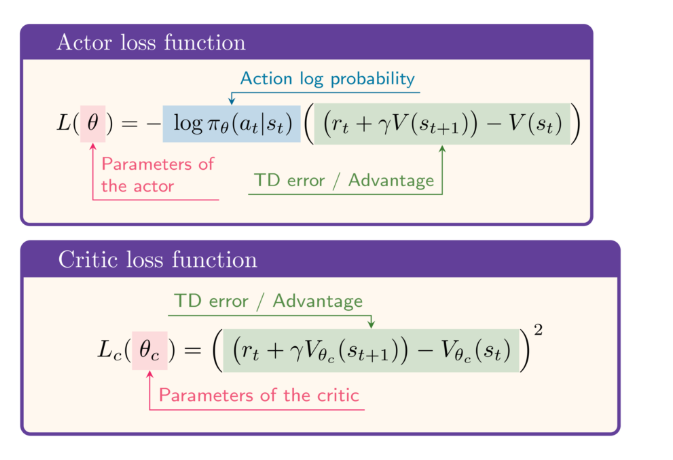

Tính TD target.

Tính loss cho mạng Actor.

Tính loss cho mạng Critic.

In [ ]:
def calculate_losses(critic_network, action_log_prob, 
                     reward, state, next_state, done):
    value = critic_network(state)
    next_value = critic_network(next_state)
    # Calculate the TD target
    td_target = (____ + gamma * ____ * (1-done))
    td_error = td_target - value
    # Calculate the actor loss
    actor_loss = -____ * ____.detach()
    # Calculate the critic loss
    critic_loss = ____
    return actor_loss, critic_loss
  
actor_loss, critic_loss = calculate_losses(
        critic_network, action_log_prob, 
        reward, state, next_state, done
)
print(round(actor_loss.item(), 2), round(critic_loss.item(), 2))

In [ ]:
"""
Gợi ý
TD target là tổng của phần thưởng và giá trị đã chiết khấu của trạng thái kế tiếp.
Tính toán loss của actor cần log-probability của hành động và TD-error đã tách (detached), đại diện cho phản hồi từ critic.
Loss của critic là bình phương TD-error (biến td_error).

def calculate_losses(critic_network, action_log_prob, 
                     reward, state, next_state, done):
    value = critic_network(state)
    next_value = critic_network(next_state)
    # Calculate the TD target
    td_target = (reward + gamma * next_value * (1-done))
    td_error = td_target - value
    # Calculate the actor loss
    actor_loss = -action_log_prob * td_error.detach()
    # Calculate the critic loss
    critic_loss = td_error ** 2
    return actor_loss, critic_loss
  
actor_loss, critic_loss = calculate_losses(
        critic_network, action_log_prob, 
        reward, state, next_state, done
)
print(round(actor_loss.item(), 2), round(critic_loss.item(), 2))

"""